In [1]:
from icrawler.builtin import BingImageCrawler

# Ducks
duck_crawler = BingImageCrawler(storage={'root_dir': 'Problem01_RawData/duck'})
duck_crawler.crawl(keyword='duck bird', max_num=200)

# Chickens
chicken_crawler = BingImageCrawler(storage={'root_dir': 'Problem01_RawData/chicken'})
chicken_crawler.crawl(keyword='chicken bird', max_num=200)

ERROR:downloader:Response status code 403, file https://static.vecteezy.com/system/resources/previews/013/416/205/large_2x/a-beautiful-aquatic-wild-bird-duck-with-a-beak-and-wings-floats-against-the-background-of-water-in-the-river-lake-pond-sea-and-green-water-lilies-photo.jpg
ERROR:downloader:Response status code 403, file https://c.pxhere.com/photos/98/7a/duck_wood_duck_wildl_wildlife_birding_water_bird-1181634.jpg
ERROR:downloader:Exception caught when downloading file https://get.pxhere.com/photo/sea-water-bird-duck-vertebrate-waterfowl-water-bird-ducks-geese-and-swans-118912.jpg, error: HTTPSConnectionPool(host='get.pxhere.com', port=443): Read timed out. (read timeout=5), remaining retry times: 2
ERROR:downloader:Exception caught when downloading file https://get.pxhere.com/photo/sea-water-bird-duck-vertebrate-waterfowl-water-bird-ducks-geese-and-swans-118912.jpg, error: HTTPSConnectionPool(host='get.pxhere.com', port=443): Read timed out. (read timeout=5), remaining retry times

In [2]:
import os
import shutil
import random

# Source folders
base_src = "Problem01_RawData"
classes = ["duck", "chicken"]

# Destination root
base_dst = "Problem01_DuckChicken_Dataset"

# Split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

# Create folder structure
for split in ["train", "validation", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(base_dst, split, cls), exist_ok=True)

def split_and_copy(class_name):
    src_folder = os.path.join(base_src, class_name)
    images = os.listdir(src_folder)

    # Shuffle randomly
    random.shuffle(images)

    total = len(images)
    train_end = int(train_ratio * total)
    val_end = train_end + int(val_ratio * total)

    train_files = images[:train_end]
    val_files = images[train_end:val_end]
    test_files = images[val_end:]

    # Copy files
    for f in train_files:
        shutil.copy(os.path.join(src_folder, f),
                    os.path.join(base_dst, "train", class_name, f))

    for f in val_files:
        shutil.copy(os.path.join(src_folder, f),
                    os.path.join(base_dst, "validation", class_name, f))

    for f in test_files:
        shutil.copy(os.path.join(src_folder, f),
                    os.path.join(base_dst, "test", class_name, f))

# Run for both classes
for cls in classes:
    split_and_copy(cls)

print("Dataset split completed!")

Dataset split completed!


In [4]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Define transformations
# Training data uses random changes (crop, flip) to help the model generalize better
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Standard normalization
])

# Validation/Test data is only resized and center cropped (no randomness)
val_test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Path to dataset folder
data_dir = "Problem01_DuckChicken_Dataset"

# 3. Load datasets using ImageFolder
train_dataset = datasets.ImageFolder(root=f"{data_dir}/train", transform=train_transform)
val_dataset = datasets.ImageFolder(root=f"{data_dir}/validation", transform=val_test_transform)
test_dataset = datasets.ImageFolder(root=f"{data_dir}/test", transform=val_test_transform)

# 4. Create DataLoaders for batching
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [5]:
# Use GPU if available, otherwise CPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print("=== DATA SUMMARY ===")
print(f"Training images: {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")
print(f"Test images: {len(test_dataset)}")
print(f"Classes found: {train_dataset.classes}")
print(f"Running on: {device}")

=== DATA SUMMARY ===
Training images: 81
Validation images: 16
Test images: 19
Classes found: ['chicken', 'duck']
Running on: cuda:0


In [6]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# 1. Load a pre-trained ResNet18 model
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# 2. Freeze all existing layers so their learned features are kept as it is
for param in model.parameters():
    param.requires_grad = False

# 3. Change the last layer to match our problem (2 output classes)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)  # Output: duck or chicken

# Move model to GPU if available, otherwise use CPU
model = model.to(device)

# 4. Define loss function and optimizer
criterion = nn.CrossEntropyLoss()

# Only train the new final layer
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

print("Model is ready")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 83.2MB/s]


Model is ready


In [7]:
# Number of times the model will go through the full dataset
epochs = 10

print("Training started...\n")

for epoch in range(epochs):
    # --- TRAINING STEP ---
    model.train()
    running_train_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()            # Reset gradients from previous step
        outputs = model(inputs)          # Get model predictions
        loss = criterion(outputs, labels) # Compute loss
        loss.backward()                  # Compute gradients
        optimizer.step()                 # Update model weights

        running_train_loss += loss.item() * inputs.size(0)

    epoch_train_loss = running_train_loss / len(train_dataset)

    # --- VALIDATION STEP ---
    model.eval()
    running_val_loss = 0.0
    correct_preds = 0

    with torch.no_grad():  # No need to track gradients here
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct_preds += torch.sum(preds == labels.data)

    epoch_val_loss = running_val_loss / len(val_dataset)
    epoch_val_acc = correct_preds.double() / len(val_dataset)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Accuracy: {epoch_val_acc:.4f}")

print("\nTraining finished!")

Training started...

Epoch 1/10 | Train Loss: 0.6203 | Val Loss: 0.4658 | Val Accuracy: 0.9375
Epoch 2/10 | Train Loss: 0.4836 | Val Loss: 0.3476 | Val Accuracy: 0.9375
Epoch 3/10 | Train Loss: 0.4103 | Val Loss: 0.2898 | Val Accuracy: 1.0000
Epoch 4/10 | Train Loss: 0.3264 | Val Loss: 0.2638 | Val Accuracy: 1.0000
Epoch 5/10 | Train Loss: 0.2514 | Val Loss: 0.2274 | Val Accuracy: 1.0000
Epoch 6/10 | Train Loss: 0.2516 | Val Loss: 0.1851 | Val Accuracy: 1.0000
Epoch 7/10 | Train Loss: 0.1897 | Val Loss: 0.1654 | Val Accuracy: 1.0000
Epoch 8/10 | Train Loss: 0.1744 | Val Loss: 0.1442 | Val Accuracy: 1.0000
Epoch 9/10 | Train Loss: 0.1745 | Val Loss: 0.1299 | Val Accuracy: 1.0000
Epoch 10/10 | Train Loss: 0.1507 | Val Loss: 0.1337 | Val Accuracy: 1.0000

Training finished!


In [8]:
from sklearn.metrics import classification_report

# Switch model to evaluation mode
model.eval()

all_preds = []
all_labels = []

# Loop through the test data (data the model has not seen before)
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)

        # Pick the class with highest score
        _, preds = torch.max(outputs, 1)

        # Move results to CPU so sklearn can use them
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Create and display the final report
class_names = train_dataset.classes
print("=== TEST SET PERFORMANCE ===\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

=== TEST SET PERFORMANCE ===

              precision    recall  f1-score   support

     chicken       1.00      1.00      1.00        11
        duck       1.00      1.00      1.00         8

    accuracy                           1.00        19
   macro avg       1.00      1.00      1.00        19
weighted avg       1.00      1.00      1.00        19



=== SAMPLE MODEL PREDICTIONS ===


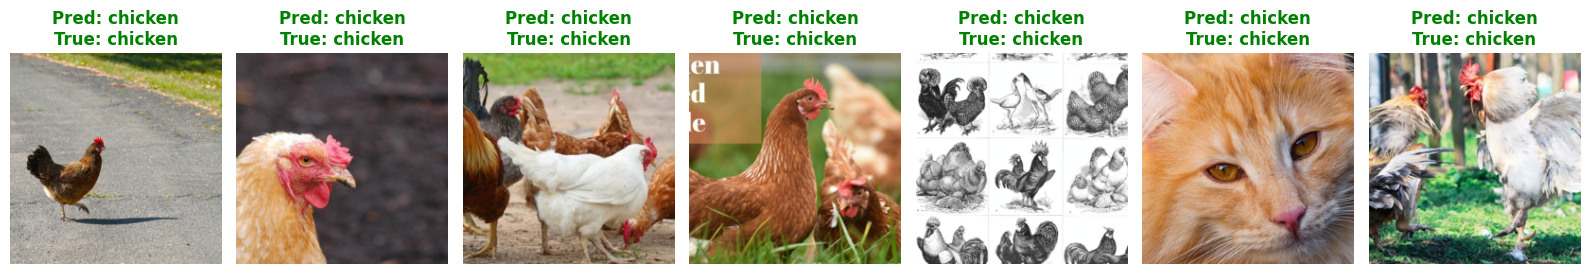

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Function to convert tensor to image and display it
def imshow(inp, title=None):
    """Show image from tensor."""
    # Change shape from (C, H, W) to (H, W, C) for plotting
    inp = inp.numpy().transpose((1, 2, 0))

    # Undo normalization to get original image colors
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)  # Keep values between 0 and 1

    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.axis('off')

# 2. Take one batch from test data and select first 7 images
inputs, labels = next(iter(test_loader))
inputs = inputs[:7]
labels = labels[:7]

# 3. Pass these images through the model to get predictions
model.eval()
with torch.no_grad():
    inputs_device = inputs.to(device)
    outputs = model(inputs_device)
    _, preds = torch.max(outputs, 1)

# Move predictions back to CPU for plotting
preds = preds.cpu()
class_names = train_dataset.classes

# 4. Show the images in a row with predictions
fig = plt.figure(figsize=(16, 4))
print("=== SAMPLE MODEL PREDICTIONS ===")

for i in range(7):
    ax = fig.add_subplot(1, 7, i+1)

    # Show prediction and actual label
    pred_name = class_names[preds[i]]
    true_name = class_names[labels[i]]

    # Green if correct, red if incorrect
    text_color = 'green' if preds[i] == labels[i] else 'red'

    imshow(inputs[i])
    ax.set_title(f"Pred: {pred_name}\nTrue: {true_name}", color=text_color, fontweight='bold')

plt.tight_layout()
plt.show()